In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
pip install ucimlrepo

  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
Using cached ucimlrepo-0.0.7-py3-none-any.whl (8.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ucimlrepo]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
df = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = df.data.features 
y = df.data.targets 
  
# metadata 
print(df.metadata) 
  
# variable information 
print(df.variables) 


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1


Accuracy 0.9298245614035088

Classifcation Report:

              precision    recall  f1-score   support

           B       0.96      0.93      0.95       187
           M       0.88      0.93      0.90        98

    accuracy                           0.93       285
   macro avg       0.92      0.93      0.92       285
weighted avg       0.93      0.93      0.93       285

Confusion Matrix:
 [[174  13]
 [  7  91]]


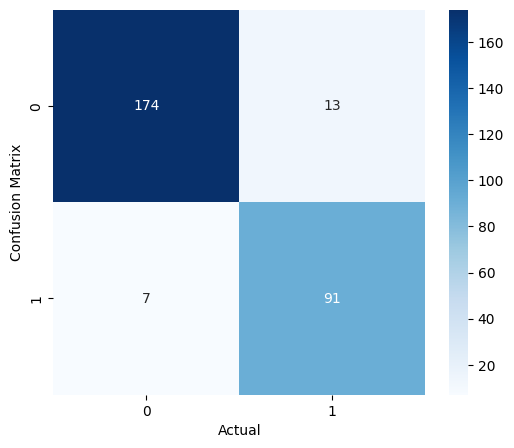

In [ ]:
#Convert to float
X = X.astype(float)
X_train, X_test,y_train, y_test= train_test_split(X,y,test_size=0.5,random_state=42)
classifier = DecisionTreeClassifier(
    criterion='entropy',
    max_depth = 4,
    random_state= 42
)
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print("\nAccuracy",accuracy)
print("\nClassifcation Report:\n")
print(classification_report(y_test,y_pred))

cm =confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt = 'd',cmap = 'Blues')
plt.xlabel("Actual")
plt.ylabel("Confusion Matrix")
plt.show()